Assignment Sesi 20 - Unsupervised Learning: PCA & Clustering
Dataset: Credit Card Dataset for Clustering
Jumlah data: ~9000 pelanggan, 18 fitur perilaku penggunaan kartu kredit

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('CC_GENERAL.csv')
print(df.shape)
df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Task 1 - Persiapan Data dan EDA Singkat

In [14]:
df = df.drop('CUST_ID', axis=1)

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

print('Missing values setelah imputasi:')
print(df.isnull().sum().sum())
print('Shape:', df.shape)

Missing values setelah imputasi:
0
Shape: (8950, 17)


In [15]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
print('Data setelah scaling (5 baris pertama):')
df_scaled.head()

Data setelah scaling (5 baris pertama):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


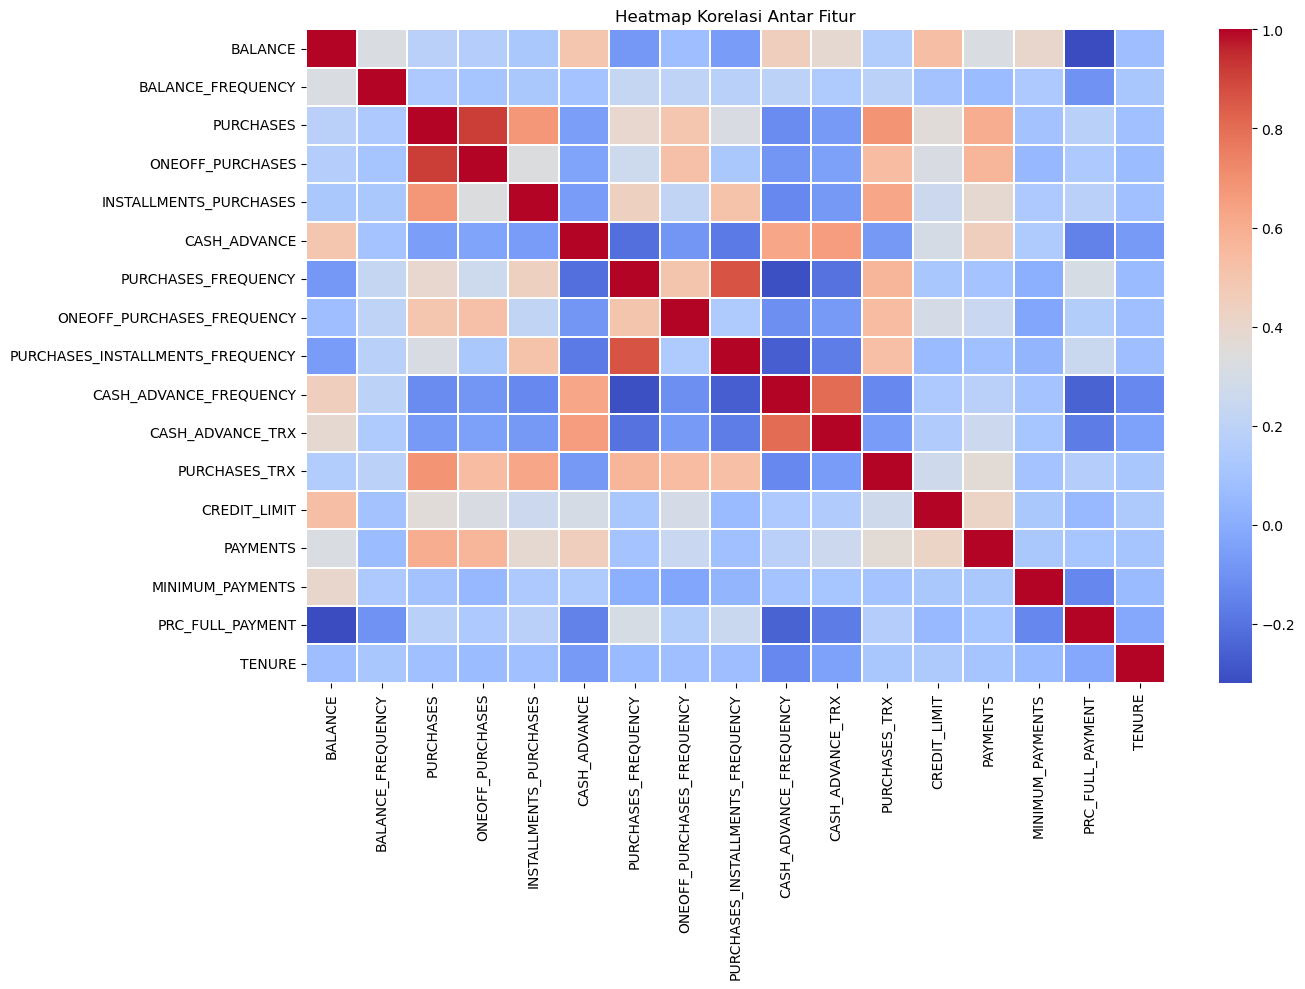

In [16]:
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

In [17]:
# Ambil pasangan korelasi tertinggi (eksklusikan diagonal)
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print('3 pasangan fitur dengan korelasi tertinggi:')
print(corr_pairs.head(6).to_string())

3 pasangan fitur dengan korelasi tertinggi:
ONEOFF_PURCHASES                  PURCHASES                           0.916845
PURCHASES                         ONEOFF_PURCHASES                    0.916845
PURCHASES_INSTALLMENTS_FREQUENCY  PURCHASES_FREQUENCY                 0.862934
PURCHASES_FREQUENCY               PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
CASH_ADVANCE_FREQUENCY            CASH_ADVANCE_TRX                    0.799561
CASH_ADVANCE_TRX                  CASH_ADVANCE_FREQUENCY              0.799561


3 pasangan fitur menunjukkan adanya redundansi informasi, yang menjadi salah satu alasan kuat untuk menggunakan PCA.

Task 2 - PCA dan Explained Variance

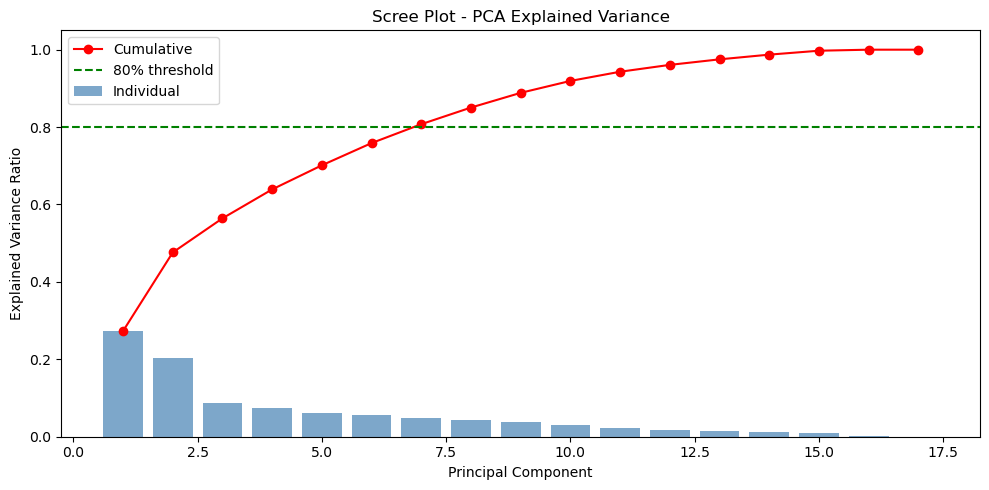

Jumlah komponen untuk mencapai 80% variance: 7
Cumulative variance dengan 7 komponen: 0.8075


In [18]:
pca_full = PCA(n_components=df_scaled.shape[1])
pca_full.fit(df_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, 'ro-', label='Cumulative')
ax.axhline(y=0.80, color='green', linestyle='--', label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot - PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

n_components_80 = np.argmax(cumulative >= 0.80) + 1
print(f'Jumlah komponen untuk mencapai 80% variance: {n_components_80}')
print(f'Cumulative variance dengan {n_components_80} komponen: {cumulative[n_components_80-1]:.4f}')

In [19]:
n_comp = n_components_80
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_comp)])
print('Shape dataset PCA:', df_pca.shape)
df_pca.head()

Shape dataset PCA: (8950, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069,-0.822155
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255,0.384282
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185,1.542496
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540,0.236644
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004,-0.698278


Jumlah komponen PCA yang dipilih ditentukan berdasarkan garis kumulatif explained variance pada scree plot, yaitu komponen yang dibutuhkan untuk mencapai minimal 80% variance. Pendekatan ini mempertahankan sebagian besar informasi dari data asli sekaligus mengurangi dimensi secara signifikan, yang berguna untuk mempercepat clustering dan menghindari curse of dimensionality.

Task 3 - K-Means Clustering

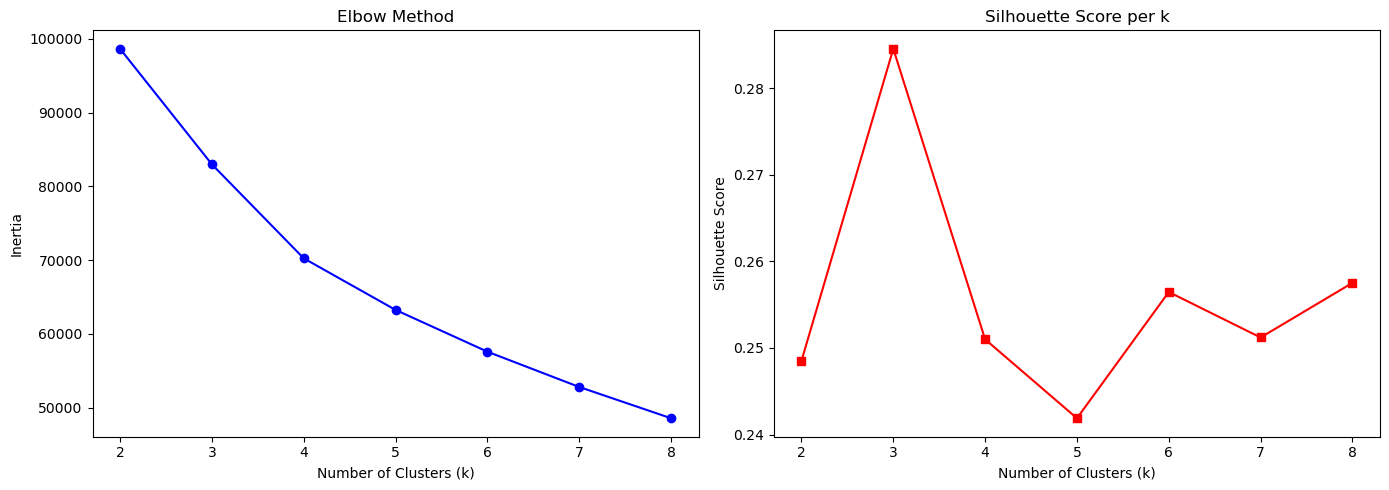

k | Inertia | Silhouette
2 | 98639.6 | 0.2485
3 | 82978.6 | 0.2846
4 | 70245.8 | 0.2510
5 | 63252.7 | 0.2419
6 | 57592.4 | 0.2565
7 | 52808.2 | 0.2512
8 | 48571.4 | 0.2575


In [20]:
inertia_list = []
sil_list = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(df_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertia_list, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(list(k_range), sil_list, 'rs-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score per k')

plt.tight_layout()
plt.show()

print('k | Inertia | Silhouette')
for k, ine, sil in zip(k_range, inertia_list, sil_list):
    print(f'{k} | {ine:.1f} | {sil:.4f}')

Pemilihan nilai k optimal:

Berdasarkan elbow method, penurunan inertia mulai melambat secara signifikan di sekitar k=3, yang menunjukkan bahwa tambahan cluster setelah itu tidak memberikan pengurangan inertia yang berarti. Silhouette score juga mencapai nilai tertinggi pada k=3 dibandingkan k lainnya. Oleh karena itu, k=3 dipilih sebagai jumlah cluster optimal karena memberikan keseimbangan terbaik antara kompaktnya cluster (inertia) dan separasi antar cluster (silhouette).

In [21]:
best_k = 3

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km_final.fit_predict(df_pca)

df['Cluster'] = labels
df_pca['Cluster'] = labels
print('Distribusi cluster:')
print(pd.Series(labels).value_counts().sort_index())

Distribusi cluster:
0    1568
1    6132
2    1250
Name: count, dtype: int64


Task 4 - Visualisasi dan Interpretasi Cluster

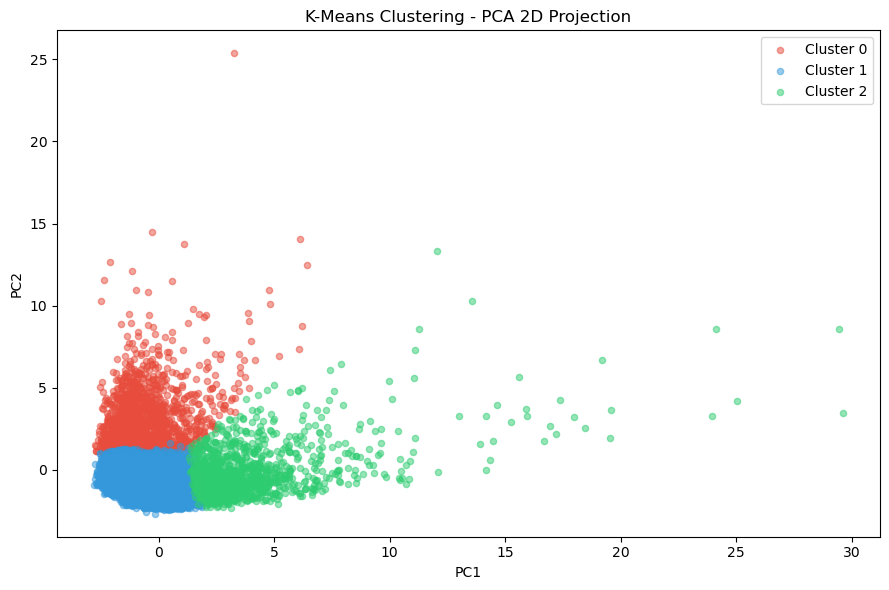

In [22]:
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(best_k):
    mask = df_pca['Cluster'] == i
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=colors[i], label=f'Cluster {i}', alpha=0.5, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering - PCA 2D Projection')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
print('Rata-rata fitur per cluster:')
cluster_profile.round(2)

Rata-rata fitur per cluster:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4009.64,0.96,390.36,249.34,141.10,3928.21,0.24,0.11,0.15,0.45,12.57,5.76,6727.59,3062.74,1778.97,0.03,11.35
1,806.00,0.84,498.33,248.26,250.39,332.79,0.46,0.13,0.34,0.07,1.23,8.60,3266.75,905.49,530.27,0.15,11.48
2,2218.02,0.98,4248.68,2711.22,1537.94,448.61,0.95,0.66,0.74,0.06,1.44,55.91,7714.60,4125.43,1216.69,0.30,11.92


Profil Cluster dan Rekomendasi Promosi:

Cluster 0 - Pengguna Pasif
Pelanggan dalam cluster ini memiliki balance rendah, frekuensi pembelian yang rendah, dan jarang menggunakan kartu kredit secara aktif. Mereka cenderung memegang kartu tetapi tidak aktif bertransaksi.
Rekomendasi promosi: Program cashback atau reward poin untuk setiap transaksi pertama guna mendorong aktivasi penggunaan kartu.

Cluster 1 - Pengguna Cash Advance
Pelanggan ini sering melakukan penarikan uang tunai (cash advance) dengan frekuensi dan jumlah yang tinggi. Perilaku ini biasanya terkait kebutuhan likuiditas jangka pendek dan bukan untuk pembelian barang.
Rekomendasi promosi: Penawaran bunga cicilan cash advance yang lebih rendah atau program konversi cash advance ke cicilan tetap dengan bunga kompetitif.

Cluster 2 - Pengguna Aktif Pembelian
Cluster ini didominasi pelanggan dengan frekuensi pembelian tinggi, baik one-off maupun cicilan, dan cenderung memiliki credit limit yang lebih besar. Mereka secara aktif menggunakan kartu untuk berbagai transaksi sehari-hari dan rutin membayar.
Rekomendasi promosi: Program loyalty premium atau upgrade ke kartu dengan limit lebih tinggi dan benefit tambahan seperti akses lounge bandara, cashback kategori khusus, atau asuransi perjalanan.